# 🧠Tarea perceptron ADELINE compuerta AND

### Carga de entradas y definición de hiperparámetros - pesos iniciales - alfa

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Datos (AND en {-1,+1})
# =========================
X = np.array([
    [-1, -1,  1],
    [ 1, -1,  1],
    [-1,  1,  1],
    [ 1,  1,  1],
], dtype=float)
Z = np.array([-1, -1, -1, +1], dtype=float)

# =========================
# Hiperparámetros / Pesos
# =========================
W = np.array([1.0, 1.0, 0.5])   # iniciales
max_epochs = 20                  # numero de epocas (manualmente)
alpha = 0.2                     # tasa de aprendizaje ( con 0.1, 0.5, etc.)

def fmt(v):
    return "[" + ", ".join(f"{x:.2f}" for x in np.array(v, dtype=float)) + "]"

print(f"Pesos iniciales: W = {fmt(W)}\n")

Pesos iniciales: W = [1.00, 1.00, 0.50]



### Entrenamiento

#### Version 1

**Importante:**
En ADALINE usamos el error continuo (Z − S).
Aunque el modelo ya esté clasificando correctamente, ese error puede seguir siendo un número pequeño (ej. 0.03 o −0.02), y nunca exactamente 0.
Por eso el código sigue ejecutando hasta llegar al max_epochs.

In [9]:
# =========================
# Entrenamiento ADALINE (version 1)
# =========================
for epoch in range(1, max_epochs + 1):
    print(f"=== Época {epoch} ===")
    errores = []

    for i, (x, z) in enumerate(zip(X, Z), start=1):
        S = np.dot(W, x)             # salida lineal
        error = z - S                # error real
        dW = alpha * error * x       # regla de aprendizaje ADALINE
        W = W + dW                   # actualización

        errores.append(error**2)     # acumular error cuadrático

        print(f"Patrón {i}: x={x}, Z={z}, S={S: .2f}, "
              f"Error={error: .2f}, ΔW={fmt(dW)}, W(nuevo)={fmt(W)}")

    mse = np.mean(errores)
    print(f"Error cuadrático medio (MSE) = {mse:.4f}\n")

    # si el error ya es muy pequeño, detener
    if mse < 0.01:
        print("✅ Convergió (error pequeño)\n")
        break

W_final = W.copy()
print(f"Pesos finales: {fmt(W_final)}\n")

=== Época 1 ===
Patrón 1: x=[-1. -1.  1.], Z=-1.0, S=-1.50, Error= 0.50, ΔW=[-0.10, -0.10, 0.10], W(nuevo)=[0.90, 0.90, 0.60]
Patrón 2: x=[ 1. -1.  1.], Z=-1.0, S= 0.60, Error=-1.60, ΔW=[-0.32, 0.32, -0.32], W(nuevo)=[0.58, 1.22, 0.28]
Patrón 3: x=[-1.  1.  1.], Z=-1.0, S= 0.92, Error=-1.92, ΔW=[0.38, -0.38, -0.38], W(nuevo)=[0.96, 0.84, -0.10]
Patrón 4: x=[1. 1. 1.], Z=1.0, S= 1.70, Error=-0.70, ΔW=[-0.14, -0.14, -0.14], W(nuevo)=[0.82, 0.70, -0.24]
Error cuadrático medio (MSE) = 1.7452

=== Época 2 ===
Patrón 1: x=[-1. -1.  1.], Z=-1.0, S=-1.76, Error= 0.76, ΔW=[-0.15, -0.15, 0.15], W(nuevo)=[0.67, 0.54, -0.09]
Patrón 2: x=[ 1. -1.  1.], Z=-1.0, S= 0.04, Error=-1.04, ΔW=[-0.21, 0.21, -0.21], W(nuevo)=[0.46, 0.75, -0.30]
Patrón 3: x=[-1.  1.  1.], Z=-1.0, S=-0.01, Error=-0.99, ΔW=[0.20, -0.20, -0.20], W(nuevo)=[0.66, 0.55, -0.50]
Patrón 4: x=[1. 1. 1.], Z=1.0, S= 0.72, Error= 0.28, ΔW=[0.06, 0.06, 0.06], W(nuevo)=[0.72, 0.61, -0.44]
Error cuadrático medio (MSE) = 0.6797

=== Época 3 =

#### Version 2

Con esta nueva versión del codigo se detendrá automáticamente si el error es muy pequeño o los pesos dejan de cambiar.

In [15]:
# =========================
# Entrenamiento ADALINE version 2 (opcional)
# =========================
for epoch in range(1, max_epochs + 1):
    print(f"=== Época {epoch} ===")
    errores = []
    W_anterior = W.copy()

    for i, (x, z) in enumerate(zip(X, Z), start=1):
        S = np.dot(W, x)
        error = z - S
        dW = alpha * error * x
        W = W + dW
        errores.append(error**2)

        print(f"Patrón {i}: x={x}, Z={z}, S={S: .2f}, "
              f"Error={error: .2f}, ΔW={fmt(dW)}, W(nuevo)={fmt(W)}")

    mse = np.mean(errores)
    print(f"Error cuadrático medio (MSE) = {mse:.6f}\n")

    # Criterio 1: MSE muy pequeño
    if mse < 0.01:
        print("✅ Convergió (error cuadrático medio pequeño)\n")
        break

    # Criterio 2: Pesos estables
    if np.allclose(W, W_anterior, atol=1e-3):
        print("✅ Convergió (pesos estables)\n")
        break

W_final = W.copy()
print(f"Pesos finales: {fmt(W_final)}\n")

=== Época 1 ===
Patrón 1: x=[-1. -1.  1.], Z=-1.0, S=-1.50, Error= 0.50, ΔW=[-0.10, -0.10, 0.10], W(nuevo)=[0.90, 0.90, 0.60]
Patrón 2: x=[ 1. -1.  1.], Z=-1.0, S= 0.60, Error=-1.60, ΔW=[-0.32, 0.32, -0.32], W(nuevo)=[0.58, 1.22, 0.28]
Patrón 3: x=[-1.  1.  1.], Z=-1.0, S= 0.92, Error=-1.92, ΔW=[0.38, -0.38, -0.38], W(nuevo)=[0.96, 0.84, -0.10]
Patrón 4: x=[1. 1. 1.], Z=1.0, S= 1.70, Error=-0.70, ΔW=[-0.14, -0.14, -0.14], W(nuevo)=[0.82, 0.70, -0.24]
Error cuadrático medio (MSE) = 1.745204

=== Época 2 ===
Patrón 1: x=[-1. -1.  1.], Z=-1.0, S=-1.76, Error= 0.76, ΔW=[-0.15, -0.15, 0.15], W(nuevo)=[0.67, 0.54, -0.09]
Patrón 2: x=[ 1. -1.  1.], Z=-1.0, S= 0.04, Error=-1.04, ΔW=[-0.21, 0.21, -0.21], W(nuevo)=[0.46, 0.75, -0.30]
Patrón 3: x=[-1.  1.  1.], Z=-1.0, S=-0.01, Error=-0.99, ΔW=[0.20, -0.20, -0.20], W(nuevo)=[0.66, 0.55, -0.50]
Patrón 4: x=[1. 1. 1.], Z=1.0, S= 0.72, Error= 0.28, ΔW=[0.06, 0.06, 0.06], W(nuevo)=[0.72, 0.61, -0.44]
Error cuadrático medio (MSE) = 0.679747

=== Época

### Gráfico de frontera de decisión (con pesos finales)

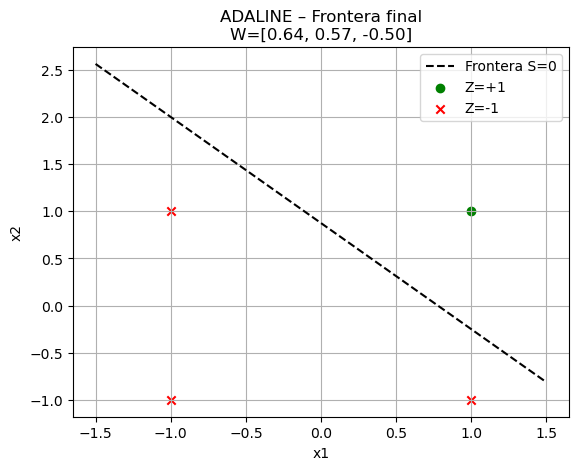

In [16]:
# =========================
# Gráfico de frontera de decisión
# =========================
def plot_decision_boundary(W, X, Z):
    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_min, x1_max = x1.min()-0.5, x1.max()+0.5
    xs = np.linspace(x1_min, x1_max, 200)

    plt.figure()
    if abs(W[1]) < 1e-8:
        plt.axvline(-W[2]/W[0], color='gray', linestyle='--', label='Frontera S=0')
    else:
        ys = (-W[0]*xs - W[2]) / W[1]
        plt.plot(xs, ys, 'k--', label='Frontera S=0')

    pos = (Z == 1)
    neg = (Z == -1)
    plt.scatter(X[pos, 0], X[pos, 1], color='green', marker='o', label='Z=+1')
    plt.scatter(X[neg, 0], X[neg, 1], color='red', marker='x', label='Z=-1')

    plt.xlabel('x1'); plt.ylabel('x2')
    plt.title(f'ADALINE – Frontera final\nW={fmt(W)}')
    plt.legend(); plt.grid(True)
    plt.show()

plot_decision_boundary(W_final, X[:, :2], Z)